In [5]:
# Import Required Libraries
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define Image Parameters
img_size = (224, 224)
batch_size = 32

# Initialize ImageDataGenerator for Training & Testing
train_datagen = ImageDataGenerator(rescale=1./255, 
                                   rotation_range=20,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load Training Data
train_generator = train_datagen.flow_from_directory(
    r'/Users/sagarkumarsahu/Desktop/project_exhibition2/archive/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical')

# Load Testing Data
test_generator = test_datagen.flow_from_directory(
    r'/Users/sagarkumarsahu/Desktop/project_exhibition2/archive/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical')

# Load Pretrained ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze layers

# Build Custom Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')  # Ensure train_generator is defined
])

# Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Model
history = model.fit(train_generator, validation_data=test_generator, epochs=5)

# Save the Model
model.save("resnet50_model.h5")


Found 928 images belonging to 4 classes.


Found 448 images belonging to 4 classes.
Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2631 - loss: 1.6716 - val_accuracy: 0.2478 - val_loss: 1.3902
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3005 - loss: 1.4157 - val_accuracy: 0.2589 - val_loss: 1.3866
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.2793 - loss: 1.3944 - val_accuracy: 0.3237 - val_loss: 1.3796
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2978 - loss: 1.3731 - val_accuracy: 0.2545 - val_loss: 1.3800
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.2843 - loss: 1.3799 - val_accuracy: 0.2589 - val_loss: 1.3887


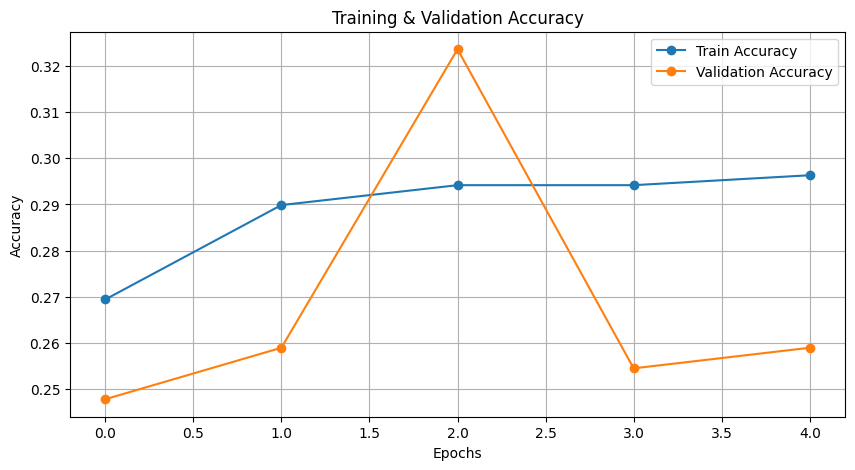

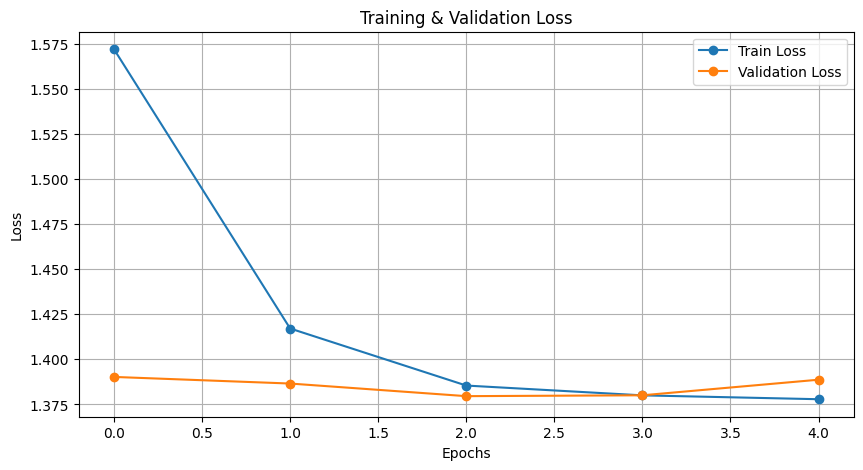

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Extract training history
history_dict = history.history

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_dict['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history_dict['loss'], label='Train Loss', marker='o')
plt.plot(history_dict['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid()
plt.show()


In [7]:
# Get true labels
true_labels = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())

# Predict probabilities
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)


14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 867ms/step


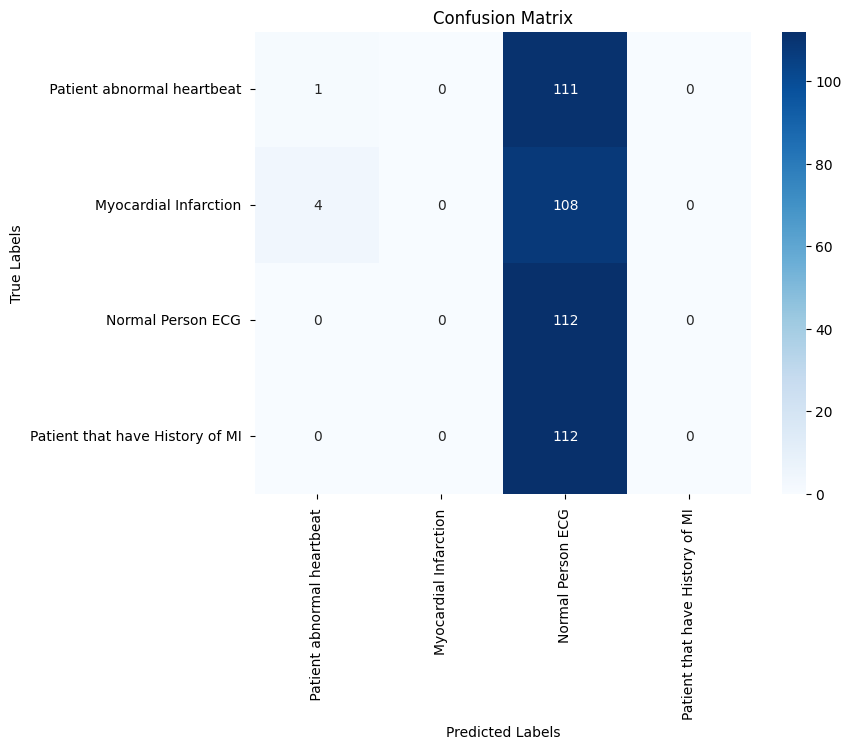

In [8]:
# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [9]:
# Print classification report
report = classification_report(true_labels, predicted_classes, target_names=class_names)
print(report)


                                  precision    recall  f1-score   support

     Patient abnormal heartbeat        0.20      0.01      0.02       112
          Myocardial Infarction        0.00      0.00      0.00       112
              Normal Person ECG        0.25      1.00      0.40       112
Patient that have History of MI        0.00      0.00      0.00       112

                        accuracy                           0.25       448
                       macro avg       0.11      0.25      0.11       448
                    weighted avg       0.11      0.25      0.11       448



/Users/sagarkumarsahu/Desktop/project_exhibition2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sagarkumarsahu/Desktop/project_exhibition2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sagarkumarsahu/Desktop/project_exhibition2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control th

In [10]:
# Compute accuracy and F1-score
accuracy = accuracy_score(true_labels, predicted_classes)
f1 = f1_score(true_labels, predicted_classes, average='weighted')

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")


Test Accuracy: 0.2522
Weighted F1 Score: 0.1052
